# Wave-following time series-- VORTICITY
This notebook produces wave-following averages of vorticity, using the wavetracks from QTRACK. Select the wave in question (whether Paulette 'second', or Rene 'main'). 
The first part of this notebook plots for a selected ensemble set, whether fluxon, fluxoff, rst_on24, 
rst_on36, or rst_on48. The last part plots vorticity from fluxon and fluxoff ensemble sets on one plot.

In [6]:
import pkg_resources
from __future__ import print_function
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd
import os
import glob
from netCDF4 import Dataset, num2date, date2num

#from AEW_module import season, AEW, AEW_CCKW

from metpy.units import units
import geocat.viz as gv

import metpy

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker 

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import wrf
from wrf import (to_np, interplevel, geo_bounds, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, destagger)

import seaborn as sns
import metpy.calc as mpcalc

In [7]:
plotsdir = '/glade/u/home/athornton/qtrack/'

In [8]:
## The following are lists to select each ensemble set and respective initialization time
variation = ['fluxon', 'rst_on24', 'rst_on36', 'rst_on48', '', 'fluxoff', '', '', '']
init_times = ['0300','0303','0306',
             '0309','0312','0315',
             '0318','0321','0400']

In [11]:
#########################################
### MAKE SELECTIONS HERE
#set = 'Fluxes on'          # try: '24 hours without fluxes'
set_name = variation[1]     # try: variation[1]
wave = 'second'             # 'second' == Paulette or 'main' == Rene
title = '24 hrs decoupled'  # What will be displayed on main plot

rst_on24_0300
53
./wrfout_d01_2020-09-03_00:00:00
WRF valid time:  2020-09-03_00:00


/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:77: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:82: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:87: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-03_06:00


/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:77: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:82: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:87: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-03_12:00


...

/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:77: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:82: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:87: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-09_06:00


/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:77: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:82: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:87: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-09_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:77: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:82: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_14629/1070945117.py:87: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


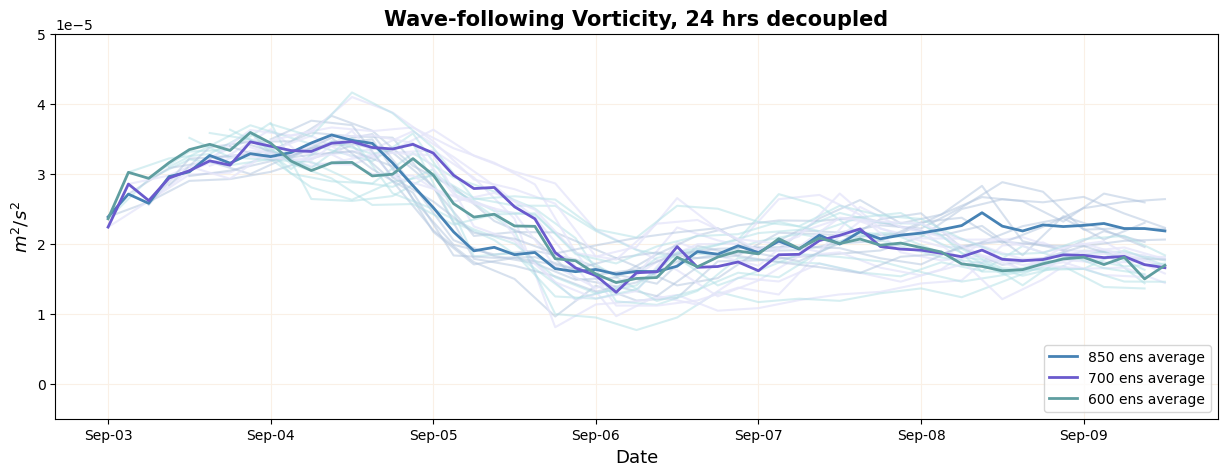

In [10]:
# Loop through wrfout files and add them to a time-series list
plt.rcParams['savefig.dpi'] = 255

fig, ax = plt.subplots(figsize=(15,5))

ax.set_title('Wave-following Vorticity, '+title, size=15, weight='bold')
ax.set_ylabel('$m^2/s^2$', size =13)
ax.set_xlabel('Date', size=13)
date_form = DateFormatter('%b-%d')
ax.xaxis.set_major_formatter(date_form)

vort850_list = []
vort700_list = []
vort600_list = []

for init_time in init_times:
    save_name = set_name +"_"+ init_time
    print(save_name)
    # Get track data
    df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+save_name+'.nc')

    # Get wrfout data
    os.chdir("/glade/campaign/univ/uncs0067/flux_experiments/cent_atl_case/init"+init_time+"z/"+set_name+"/")
    datafiles = sorted(glob.glob("./wrfout*"))
    numfiles=len(datafiles)
    # Our track data is 6hrly and wrf is 3hrly, so get every other file to align to track
    datafiles_6hr = datafiles[::2]
    print(numfiles)
    print(datafiles[0])
    start_time ='2020-09-'+init_time[:2]+' '+init_time[2:]+':00'
    
    # Grab lats and lons that fall without our simulation's time window
    times_list = pd.date_range(start=start_time, end='2020-09-09 12:00', freq='6h')
    wave_track_lons = df.lon[-len(times_list):]
    wave_track_lats = df.lat[-len(times_list):]
    wrf_out_data = xr.open_dataset(datafiles_6hr[0])  
    p =wrf_out_data['P']

    vo850_list = []
    vo700_list = []
    vo600_list = []
    for i in range(0,len(datafiles_6hr)):
        ncfile = Dataset(datafiles_6hr[i])
        Time=wrf.extract_times(ncfile, timeidx=0, method='cat', squeeze=True, cache=None, meta=False, do_xtime=False)
        timestr=(str(Time))
        # Set up one time string for plot titles, another for file names
        titletime=(timestr[0:10]+' '+timestr[11:16])
        filetime=(timestr[0:10]+'_'+timestr[11:16])
        print('WRF valid time: ',filetime)
    
        wrf_out_data = xr.open_dataset(datafiles_6hr[i])  
        
        # Get all the variables we need
        ua = wrf_out_data["U"]
        va = wrf_out_data["V"]
    
        lats, lons = latlon_coords(wrf_out_data['P'])
        lats_np = to_np(lats)
        lons_np = to_np(lons)
        lats_np = lats_np[0,:,0]
        lons_np = lons_np[0,0,:]
        
        # Unstagger the winds to match the pressure grid
        ua = destagger(ua, stagger_dim=3)             # Unstagger U in the x-direction
        va = destagger(va, stagger_dim=2)             # Unstagger V in the x-direction
    
        # Grid spacing for vorticity calculation
        dx = ncfile.DX * units("m")
        dy = ncfile.DY * units("m")
        
        u_winds = xr.DataArray(ua)[0]
        v_winds = xr.DataArray(va)[0]
        
    
        u_600 = u_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
        v_600 = v_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
        vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
        vo600=to_np(vo600)
    
        u_700 = u_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds
        v_700 = v_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds 
        vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
        vo700=to_np(vo700)
        
        u_850 = u_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
        v_850 = v_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
        vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)
        vo850=to_np(vo850)
        
        # Lat, Lon cooridante of center of square we are interested in
        lat_lon = [wave_track_lats[i],wave_track_lons[i]]                 
        x_ycenter = wrf.ll_to_xy(ncfile, lat_lon[0], lat_lon[1])
    
        # specify how big you want the wave-following box to be
        delta = 50                             # in grid points 

        # select data in this wave-following box and average across it
        avg_850 = vo850[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
        avg_700 = vo700[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
        avg_600 = vo600[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
    
        vo850_list.append(avg_850)
        vo700_list.append(avg_700)
        vo600_list.append(avg_600)


    date_list = pd.date_range(start=start_time, end='2020-09-09 12:00:00', freq='6h')
    df=pd.DataFrame(vo850_list)
    df['date']=date_list
    df=df.set_index('date')
    vort850_list.append(df)    # for ensemble average

    df2=pd.DataFrame(vo700_list)
    df2['date']=date_list
    df2=df2.set_index('date')
    vort700_list.append(df2)   # for ensemble average

    df3=pd.DataFrame(vo600_list)
    df3['date']=date_list
    df3=df3.set_index('date')
    vort600_list.append(df3)   # for ensemble average

    ax.plot(date_list, vo850_list, color='lightsteelblue',alpha=0.5)
    ax.plot(date_list, vo700_list, color='lavender',alpha=0.8)
    ax.plot(date_list, vo600_list, color='powderblue',alpha=0.5)

ens_avg = pd.concat(vort850_list, join='outer', axis=1).fillna(np.nan)
ens_avg = ens_avg.mean(axis=1)
ax.plot(ens_avg, color='steelblue', label='850 ens average', linewidth=2.)

ens_avg2 = pd.concat(vort700_list, join='outer', axis=1).fillna(np.nan)
ens_avg2 = ens_avg2.mean(axis=1)
ax.plot(ens_avg2, color='slateblue', label='700 ens average', linewidth=2.)

ens_avg3 = pd.concat(vort600_list, join='outer', axis=1).fillna(np.nan)
ens_avg3 = ens_avg3.mean(axis=1)
ax.plot(ens_avg3, color='cadetblue', label='600 ens average', linewidth=2.)

ax.grid(color='linen')
ax.legend(loc='lower right')
ax.set_ylim(-0.000005,0.00005)
plt.savefig(plotsdir+'wave_following_ens_vort'+set_name+'.png')


## COMBINE FLUXON AND FLUXOFF

fluxon_0300
53
./wrfout_d01_2020-09-03_00:00:00
WRF valid time:  2020-09-03_00:00


/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:76: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:81: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:86: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-03_06:00


/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:76: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:81: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:86: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-03_12:00


...

/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:200: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:205: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:210: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-09_06:00


/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:200: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:205: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:210: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-09_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:200: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:205: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_39336/2876634875.py:210: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


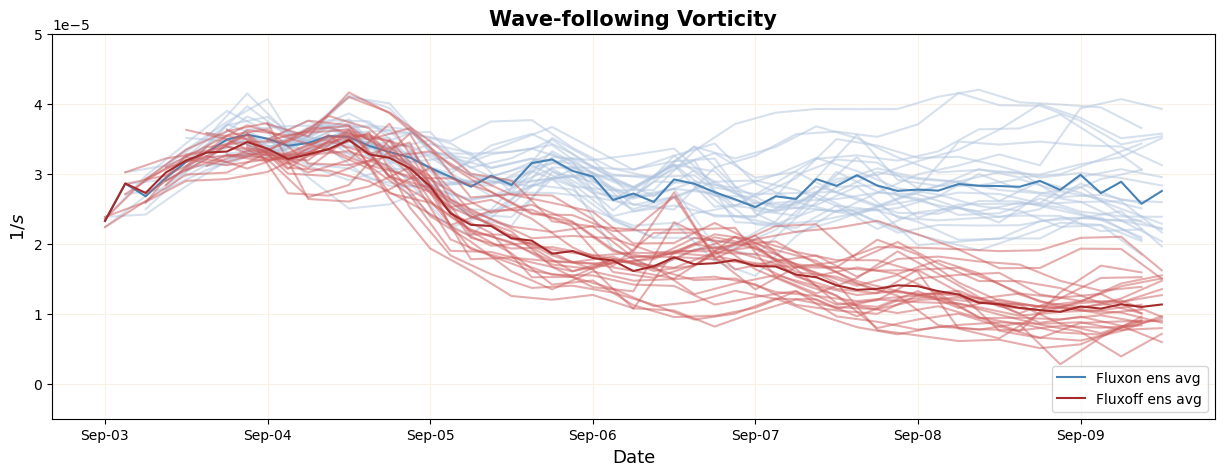

In [6]:
# Set up loop to run same plots for multiple different times (assume here that we have 1 time per wrfout file)
plt.rcParams['savefig.dpi'] = 255

fig, ax = plt.subplots(figsize=(15,5))

ax.set_title('Wave-following Vorticity', size=15, weight='bold')
#plt.title('Lat: ('+str(lat_min)+'N ,'+str(lat_max)+'N), Lon: ('+str(lon_min)+'W ,'+str(lon_max)+'W)', loc='right')
ax.set_ylabel('$1/s$', size =13)
ax.set_xlabel('Date', size=13)
date_form = DateFormatter('%b-%d')
ax.xaxis.set_major_formatter(date_form)

set_name = variation[0]

vort850_list = []
vort700_list = []
vort600_list = []

for init_time in init_times:
    save_name = set_name +"_"+ init_time
    print(save_name)
    df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+save_name+'.nc')

    os.chdir("/glade/campaign/univ/uncs0067/flux_experiments/cent_atl_case/init"+init_time+"z/"+set_name+"/")
    datafiles = sorted(glob.glob("./wrfout*"))
    numfiles=len(datafiles)
    datafiles_6hr = datafiles[::2]
    print(numfiles)
    print(datafiles[0])
    start_time ='2020-09-'+init_time[:2]+' '+init_time[2:]+':00'
    times_list = pd.date_range(start=start_time, end='2020-09-09 12:00', freq='6h')
    wave_track_lons = df.lon[-len(times_list):]
    wave_track_lats = df.lat[-len(times_list):]
    wrf_out_data = xr.open_dataset(datafiles_6hr[0])  
    p =wrf_out_data['P']

    vo850_list = []
    vo700_list = []
    vo600_list = []
    for i in range(0,len(datafiles_6hr)):
        # for j in range(0,1):
        ncfile = Dataset(datafiles_6hr[i])
        Time=wrf.extract_times(ncfile, timeidx=0, method='cat', squeeze=True, cache=None, meta=False, do_xtime=False)
        timestr=(str(Time))
        # Set up one time string for plot titles, another for file names
        titletime=(timestr[0:10]+' '+timestr[11:16])
        filetime=(timestr[0:10]+'_'+timestr[11:16])
        print('WRF valid time: ',filetime)
    
        wrf_out_data = xr.open_dataset(datafiles_6hr[i])  
        
        # Get all the variables we need
        ua = wrf_out_data["U"]
        va = wrf_out_data["V"]
    
        lats, lons = latlon_coords(wrf_out_data['P'])
        lats_np = to_np(lats)
        lons_np = to_np(lons)
        lats_np = lats_np[0,:,0]
        lons_np = lons_np[0,0,:]
        
        # Unstagger the winds to match the pressure grid
        ua = destagger(ua, stagger_dim=3)             # Unstagger U in the x-direction
        va = destagger(va, stagger_dim=2)             # Unstagger V in the x-direction
    
        # Grid spacing for vorticity calculation
        dx = ncfile.DX * units("m")
        dy = ncfile.DY * units("m")
        
        u_winds = xr.DataArray(ua)[0]
        v_winds = xr.DataArray(va)[0]
        
    
        u_600 = u_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
        v_600 = v_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
        vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
        vo600=to_np(vo600)
    
        u_700 = u_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds
        v_700 = v_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds 
        vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
        vo700=to_np(vo700)
        
        u_850 = u_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
        v_850 = v_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
        vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)
        vo850=to_np(vo850)
        
        lat_lon = [wave_track_lats[i],wave_track_lons[i]]                 # Lat, Lon cooridante of center of square we are interested in
        
        x_ycenter = wrf.ll_to_xy(ncfile, lat_lon[0], lat_lon[1])
    
        # specify how big you want the wave-following box to be
        delta = 50                                      # in grid points 
    
        avg_850 = vo850[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
        avg_700 = vo700[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
        avg_600 = vo600[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
    
        vo850_list.append(avg_850)
        vo700_list.append(avg_700)
        vo600_list.append(avg_600)


    date_list = pd.date_range(start=start_time, end='2020-09-09 12:00:00', freq='6h')
    df=pd.DataFrame(vo850_list)
    df['date']=date_list
    df=df.set_index('date')
    vort850_list.append(df)

    df2=pd.DataFrame(vo700_list)
    df2['date']=date_list
    df2=df2.set_index('date')
    vort700_list.append(df2)

    df3=pd.DataFrame(vo600_list)
    df3['date']=date_list
    df3=df3.set_index('date')
    vort600_list.append(df3)

    ax.plot(date_list, vo850_list, color='lightsteelblue',alpha=0.5)
    ax.plot(date_list, vo700_list, color='lightsteelblue',alpha=0.5)
    ax.plot(date_list, vo600_list, color='lightsteelblue',alpha=0.5)

ens_avg = pd.concat(vort850_list, join='outer', axis=1).fillna(np.nan)
ens_avg = ens_avg.mean(axis=1)

ens_avg2 = pd.concat(vort700_list, join='outer', axis=1).fillna(np.nan)
ens_avg2 = ens_avg2.mean(axis=1)

ens_avg3 = pd.concat(vort600_list, join='outer', axis=1).fillna(np.nan)
ens_avg3 = ens_avg3.mean(axis=1)

fluxon_avg = (ens_avg + ens_avg2 + ens_avg3)/3
ax.plot(fluxon_avg, color='steelblue', label="Fluxon ens avg")


set_name = variation[5]
vort850_list = []
vort700_list = []
vort600_list = []

for init_time in init_times:
    save_name = set_name +"_"+ init_time
    print(save_name)
    df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+save_name+'.nc')

    os.chdir("/glade/campaign/univ/uncs0067/flux_experiments/cent_atl_case/init"+init_time+"z/"+set_name+"/")
    datafiles = sorted(glob.glob("./wrfout*"))
    numfiles=len(datafiles)
    datafiles_6hr = datafiles[::2]
    print(numfiles)
    print(datafiles[0])
    start_time ='2020-09-'+init_time[:2]+' '+init_time[2:]+':00'
    times_list = pd.date_range(start=start_time, end='2020-09-09 12:00', freq='6h')
    wave_track_lons = df.lon[-len(times_list):]
    wave_track_lats = df.lat[-len(times_list):]
    wrf_out_data = xr.open_dataset(datafiles_6hr[0])  
    p =wrf_out_data['P']

    vo850_list = []
    vo700_list = []
    vo600_list = []
    for i in range(0,len(datafiles_6hr)):
        # for j in range(0,1):
        ncfile = Dataset(datafiles_6hr[i])
        Time=wrf.extract_times(ncfile, timeidx=0, method='cat', squeeze=True, cache=None, meta=False, do_xtime=False)
        timestr=(str(Time))
        # Set up one time string for plot titles, another for file names
        titletime=(timestr[0:10]+' '+timestr[11:16])
        filetime=(timestr[0:10]+'_'+timestr[11:16])
        print('WRF valid time: ',filetime)
    
        wrf_out_data = xr.open_dataset(datafiles_6hr[i])  
        
        # Get all the variables we need
        ua = wrf_out_data["U"]
        va = wrf_out_data["V"]
    
        lats, lons = latlon_coords(wrf_out_data['P'])
        lats_np = to_np(lats)
        lons_np = to_np(lons)
        lats_np = lats_np[0,:,0]
        lons_np = lons_np[0,0,:]
        
        # Unstagger the winds to match the pressure grid
        ua = destagger(ua, stagger_dim=3)             # Unstagger U in the x-direction
        va = destagger(va, stagger_dim=2)             # Unstagger V in the x-direction
    
        # Grid spacing for vorticity calculation
        dx = ncfile.DX * units("m")
        dy = ncfile.DY * units("m")
        
        u_winds = xr.DataArray(ua)[0]
        v_winds = xr.DataArray(va)[0]
        
    
        u_600 = u_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
        v_600 = v_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
        vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
        vo600=to_np(vo600)
    
        u_700 = u_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds
        v_700 = v_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds 
        vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
        vo700=to_np(vo700)
        
        u_850 = u_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
        v_850 = v_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
        vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)
        vo850=to_np(vo850)
        
        lat_lon = [wave_track_lats[i],wave_track_lons[i]]                 # Lat, Lon cooridante of center of square we are interested in
        
        x_ycenter = wrf.ll_to_xy(ncfile, lat_lon[0], lat_lon[1])
    
        # specify how big you want the wave-following box to be
        delta = 50                                      # in grid points 
    
        avg_850 = vo850[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
        avg_700 = vo700[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
        avg_600 = vo600[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
    
        vo850_list.append(avg_850)
        vo700_list.append(avg_700)
        vo600_list.append(avg_600)

    date_list = pd.date_range(start=start_time, end='2020-09-09 12:00:00', freq='6h')
    df=pd.DataFrame(vo850_list)
    df['date']=date_list
    df=df.set_index('date')
    vort850_list.append(df)

    df2=pd.DataFrame(vo700_list)
    df2['date']=date_list
    df2=df2.set_index('date')
    vort700_list.append(df2)

    df3=pd.DataFrame(vo600_list)
    df3['date']=date_list
    df3=df3.set_index('date')
    vort600_list.append(df3)

    ax.plot(date_list, vo850_list, color='indianred',alpha=0.5)
    ax.plot(date_list, vo700_list, color='indianred',alpha=0.5)
    ax.plot(date_list, vo600_list, color='indianred',alpha=0.5)

ens_avg = pd.concat(vort850_list, join='outer', axis=1).fillna(np.nan)
ens_avg = ens_avg.mean(axis=1)

ens_avg2 = pd.concat(vort700_list, join='outer', axis=1).fillna(np.nan)
ens_avg2 = ens_avg2.mean(axis=1)

ens_avg3 = pd.concat(vort600_list, join='outer', axis=1).fillna(np.nan)
ens_avg3 = ens_avg3.mean(axis=1)

fluxoff_avg = (ens_avg + ens_avg2 + ens_avg3)/3
ax.plot(fluxoff_avg, color='brown', label="Fluxoff ens avg")

ax.grid(color='linen')
ax.legend(loc='lower right')
ax.set_ylim(-0.000005,0.00005)
#plt.savefig(plotsdir+'wave_following_ens_fluxonoff.png')